In [ ]:
#scikit learns coverts thedf into array , look out for t hat

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [6]:
dff= pd.read_csv('titanic_train.csv' , usecols = ['Age', 'Survived', 'Fare', 'SibSp','Parch'])

In [7]:
dff['family'] = dff['SibSp'] + dff['Parch']


In [10]:
dff

,Survived,Age,SibSp,Parch,Fare,family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0
...,...,...,...,...,...,...
886,0,27.0,0,0,13.0000,0
887,1,19.0,0,0,30.0000,0
888,0,NaN,1,2,23.4500,3
889,1,26.0,0,0,30.0000,0


In [11]:
df = dff.drop(columns = ['SibSp','Parch'])


In [15]:
df


,Survived,Age,Fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0
...,...,...,...,...
886,0,27.0,13.0000,0
887,1,19.0,30.0000,0
888,0,NaN,23.4500,3
889,1,26.0,30.0000,0


In [17]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
family        0
dtype: int64

In [18]:
#train  test split
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [19]:
x_train , x_test, y_train , y_test = train_test_split(df.drop(columns = ['Survived']), df['Survived'] , test_size = 0.2, random_state = 42)

In [20]:
x_train.shape , x_test.shape


((712, 3), (179, 3))

In [21]:
x_train.isnull().mean()
#age can be filled using simple imputer

Age       0.196629
Fare      0.000000
family    0.000000
dtype: float64

In [22]:
x_test.isnull().mean()


Age       0.206704
Fare      0.000000
family    0.000000
dtype: float64

In [23]:
x_train['Age'].mean()

np.float64(29.498846153846156)

In [25]:
mean_age = x_train['Age'].mean()
med_age = x_train['Age'].median()
mean_age , med_age


(np.float64(29.498846153846156), np.float64(28.0))

In [26]:
#using pandas to fill
x_train['Age_median'] = x_train['Age'].fillna(med_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

In [27]:
x_train.sample(11)


,Age,Fare,family,Age_median,Age_mean
7,2.0,21.0750,4,2.0,2.000000
730,29.0,211.3375,0,29.0,29.000000
123,32.5,13.0000,0,32.5,32.500000
488,30.0,8.0500,0,30.0,30.000000
402,21.0,9.8250,1,21.0,21.000000
390,36.0,120.0000,3,36.0,36.000000
692,NaN,56.4958,0,28.0,29.498846
722,34.0,13.0000,0,34.0,34.000000
632,32.0,30.5000,0,32.0,32.000000
724,27.0,53.1000,1,27.0,27.000000


In [28]:
print('Og age variable variable :' , x_train['Age'].var())
print(' age variance after median imputation  :' , x_train['Age_median'].var())
print(' age variance after mean imputation  :' , x_train['Age_mean'].var())
#there shouldnt be drastic changes in the variance

Og age variable variable : 210.2517072477435
 age variance after median imputation  : 169.20731007048155
 age variance after mean imputation  : 168.85193366872227


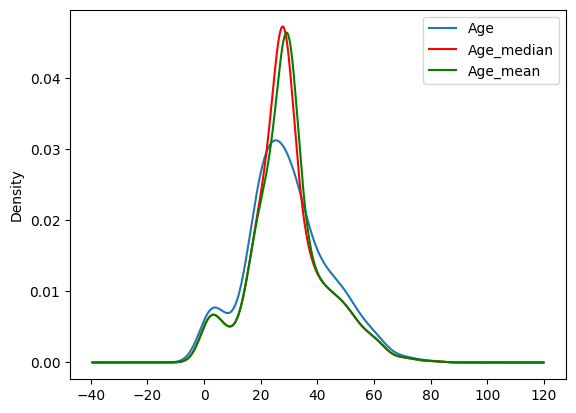

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)


x_train['Age'].plot(kind ='kde', ax = ax)

x_train['Age_median'].plot(kind= 'kde', ax = ax , color ='red')

x_train['Age_mean'].plot(kind = 'kde', ax = ax , color = 'green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines , labels , loc ='best')

In [30]:
x_train.cov()

,Age,Fare,family,Age_median,Age_mean
Age,210.251707,71.580633,-6.993325,210.251707,210.251707
Fare,71.580633,2700.831981,18.495747,61.261919,57.485994
family,-6.993325,18.495747,2.830892,-5.587710,-5.616299
Age_median,210.251707,61.261919,-5.587710,169.207310,168.851934
Age_mean,210.251707,57.485994,-5.616299,168.851934,168.851934


In [31]:
x_train.corr()


,Age,Fare,family,Age_median,Age_mean
Age,1.000000,0.088103,-0.319651,1.000000,1.000000
Fare,0.088103,1.000000,0.211525,0.090622,0.085126
family,-0.319651,0.211525,1.000000,-0.255307,-0.256883
Age_median,1.000000,0.090622,-0.255307,1.000000,0.998949
Age_mean,1.000000,0.085126,-0.256883,0.998949,1.000000


<Axes: >

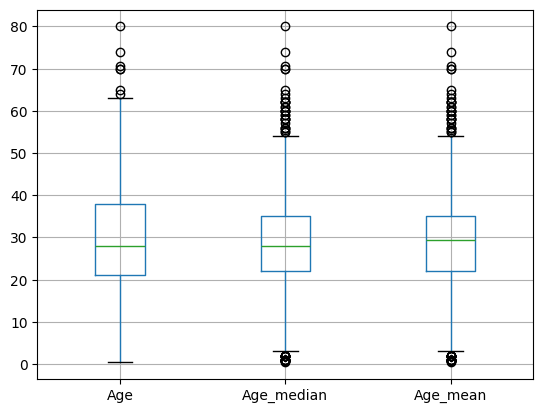

In [34]:
x_train[['Age', 'Age_median', 'Age_mean']].boxplot()
#too many outlier is median and mean age


**Using SKlean for imputation instead of pandas**

In [35]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 2)


In [38]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy = 'mean')

In [39]:
trf = ColumnTransformer([
    ( 'imputer1' ,imputer1, ['Age']),

], remainder = 'passthrough')

In [40]:
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. 

In [41]:
trf.named_transformers_['imputer1'].statistics_


array([28.75])

In [42]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [43]:
x_train


array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))